# Chest X-Ray Classification with XGBoost Variants

This notebook implements Exercise 3 from the assignment, focusing on the chest X-ray dataset classification using different XGBoost approaches:

1. PCA + XGBoost: Dimensionality reduction with PCA followed by XGBoost
2. VGG16 + XGBoost: Transfer learning using VGG16 as feature extractor followed by XGBoost
3. Raw + XGBoost: Direct application of XGBoost on flattened image features

We evaluate each approach with different training data sizes (20%, 40%, 60%, 80%) and compare performance metrics.

In [1]:
# Cell 1: Install & Import Libraries
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import xgboost as xgb
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model

plt.style.use('default')
sns.set_palette("husl")

C:\Users\vijay\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Cell 2: Configuration
TRAIN_DIR = r"C:\Users\vijay\Downloads\archive (2)\chest_xray\train"
TEST_DIR  = r"C:\Users\vijay\Downloads\archive (2)\chest_xray\test"

IMG_SIZE = (224, 224)
RANDOM_STATE = 42
TRAINING_FRACTIONS = [0.2, 0.4, 0.6, 0.8]

XGBOOST_PARAMS = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': RANDOM_STATE,
    'n_estimators': 200,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'n_jobs': -1
}

In [3]:
# Cell 3: Data Loading Function
def load_data(folder_path, img_size=IMG_SIZE):
    X, y = [], []
    for cls in os.listdir(folder_path):
        cls_dir = os.path.join(folder_path, cls)
        if not os.path.isdir(cls_dir): continue
        for fname in os.listdir(cls_dir):
            if not fname.lower().endswith(('.jpg','jpeg','png')): continue
            img = cv2.imread(os.path.join(cls_dir, fname))
            img = cv2.resize(img, img_size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
            X.append(img)
            y.append(cls)
    return np.array(X), np.array(y)

In [4]:
# Cell 4: Load & Encode Labels
X_train, y_train = load_data(TRAIN_DIR)
X_test,  y_test  = load_data(TEST_DIR)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

In [5]:
# Cell 5: FeatureExtractor Class
class FeatureExtractor:
    def __init__(self):
        self.scaler = StandardScaler()
        self.pca = None
        self.vgg = None

    def extract_pca(self, X_train, X_test, n_components=100):
        Xtr = X_train.reshape(len(X_train), -1)
        Xte = X_test.reshape(len(X_test), -1)
        Xtr_s = self.scaler.fit_transform(Xtr)
        Xte_s = self.scaler.transform(Xte)
        self.pca = PCA(n_components=min(n_components, Xtr_s.shape[1]), random_state=RANDOM_STATE)
        return self.pca.fit_transform(Xtr_s), self.pca.transform(Xte_s)

    def extract_vgg16(self, X_train, X_test):
        if self.vgg is None:
            base = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE,3))
            x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
            self.vgg = Model(inputs=base.input, outputs=x)
        tr = preprocess_input((X_train*255).astype(np.float32))
        te = preprocess_input((X_test*255).astype(np.float32))
        return self.vgg.predict(tr, batch_size=32), self.vgg.predict(te, batch_size=32)

    def extract_raw(self, X_train, X_test):
        Xtr = X_train.reshape(len(X_train), -1)
        Xte = X_test.reshape(len(X_test), -1)
        return self.scaler.fit_transform(Xtr), self.scaler.transform(Xte)

fe = FeatureExtractor()

In [6]:
# Cell 6: Evaluation Function
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    rpt = classification_report(y, y_pred, output_dict=True, zero_division=0)
    f1 = rpt['1']['f1-score'] if '1' in rpt else rpt['macro avg']['f1-score']
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.shape==(2,2) else (0,0,0,0)
    sens = tp/(tp+fn) if tp+fn else 0
    spec = tn/(tn+fp) if tn+fp else 0
    return {'Method':name, 'Training_Size':None, 'Accuracy':round(acc,4),
            'F1-Score':round(f1,4), 'Sensitivity':round(sens,4),
            'Specificity':round(spec,4)}, cm


In [7]:
# Cell 7: Chest X-Ray Experiments
results = []

# PCA + XGBoost
print("Extracting PCA features...")
Xtr_pca, Xte_pca = fe.extract_pca(X_train, X_test, n_components=100)
for frac in TRAINING_FRACTIONS:
    print(f"Training PCA+XGBoost with {int(frac*100)}% of data...")
    # Using train_test_split to get a subset of training data
    X_train_subset, _, y_train_subset, _ = train_test_split(
        Xtr_pca, y_train_enc, train_size=frac,
        random_state=RANDOM_STATE, stratify=y_train_enc
    )
    model = XGBClassifier(**XGBOOST_PARAMS); model.fit(X_train_subset, y_train_subset)
    name = f"PCA+XGBoost-{int(frac*100)}%"
    res, _ = evaluate(model, Xte_pca, y_test_enc, name)
    res['Training_Size'] = f"{int(frac*100)}%"; results.append(res)

# VGG16 + XGBoost
print("Extracting VGG16 features...")
Xtr_vgg, Xte_vgg = fe.extract_vgg16(X_train, X_test)
for frac in TRAINING_FRACTIONS:
    print(f"Training VGG16+XGBoost with {int(frac*100)}% of data...")
    X_train_subset, _, y_train_subset, _ = train_test_split(
        Xtr_vgg, y_train_enc, train_size=frac,
        random_state=RANDOM_STATE, stratify=y_train_enc
    )
    model = XGBClassifier(**XGBOOST_PARAMS); model.fit(X_train_subset, y_train_subset)
    name = f"VGG16+XGBoost-{int(frac*100)}%"
    res, _ = evaluate(model, Xte_vgg, y_test_enc, name)
    res['Training_Size'] = f"{int(frac*100)}%"; results.append(res)

# Raw XGBoost
print("Extracting raw features...")
Xtr_raw, Xte_raw = fe.extract_raw(X_train, X_test)
for frac in TRAINING_FRACTIONS:
    print(f"Training Raw+XGBoost with {int(frac*100)}% of data...")
    X_train_subset, _, y_train_subset, _ = train_test_split(
        Xtr_raw, y_train_enc, train_size=frac,
        random_state=RANDOM_STATE, stratify=y_train_enc
    )
    params = XGBOOST_PARAMS.copy(); params.update(max_depth=3, n_estimators=100, subsample=0.7, colsample_bytree=0.7)
    model = XGBClassifier(**params); model.fit(X_train_subset, y_train_subset)
    name = f"Raw+XGBoost-{int(frac*100)}%"
    res, _ = evaluate(model, Xte_raw, y_test_enc, name)
    res['Training_Size'] = f"{int(frac*100)}%"; results.append(res)

Extracting PCA features...
Training PCA+XGBoost with 20% of data...
Training PCA+XGBoost with 40% of data...
Training PCA+XGBoost with 60% of data...
Training PCA+XGBoost with 80% of data...
Extracting VGG16 features...
163/163 ━━━━━━━━━━━━━━━━━━━━ 1459s 9s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 187s 9s/step
Training VGG16+XGBoost with 20% of data...
Training VGG16+XGBoost with 40% of data...
Training VGG16+XGBoost with 60% of data...
Training VGG16+XGBoost with 80% of data...
Extracting raw features...
Training Raw+XGBoost with 20% of data...
Training Raw+XGBoost with 40% of data...
Training Raw+XGBoost with 60% of data...
Training Raw+XGBoost with 80% of data...


In [8]:
# Cell 8: Compile & Display Results
df = pd.DataFrame(results)
print(df.to_string(index=False))
df.to_csv('chest_xray_xgboost_results.csv', index=False)

           Method Training_Size  Accuracy  F1-Score  Sensitivity  Specificity
  PCA+XGBoost-20%           20%    0.7404    0.8262       0.9872       0.3291
  PCA+XGBoost-40%           40%    0.7580    0.8353       0.9821       0.3846
  PCA+XGBoost-60%           60%    0.7564    0.8351       0.9872       0.3718
  PCA+XGBoost-80%           80%    0.7548    0.8332       0.9795       0.3803
VGG16+XGBoost-20%           20%    0.7404    0.8258       0.9846       0.3333
VGG16+XGBoost-40%           40%    0.7436    0.8283       0.9897       0.3333
VGG16+XGBoost-60%           60%    0.7628    0.8398       0.9949       0.3761
VGG16+XGBoost-80%           80%    0.7660    0.8420       0.9974       0.3803
  Raw+XGBoost-20%           20%    0.7179    0.8128       0.9795       0.2821
  Raw+XGBoost-40%           40%    0.7147    0.8126       0.9897       0.2564
  Raw+XGBoost-60%           60%    0.7292    0.8200       0.9872       0.2991
  Raw+XGBoost-80%           80%    0.7356    0.8239       0.9897

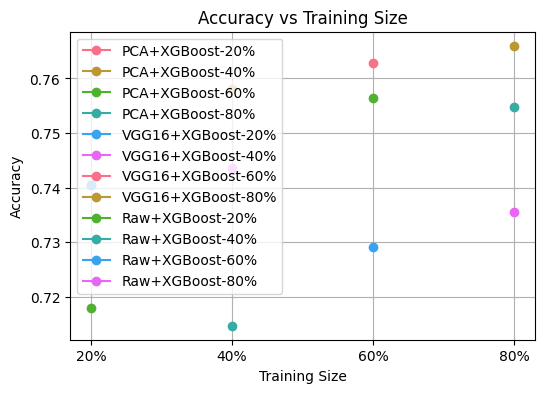

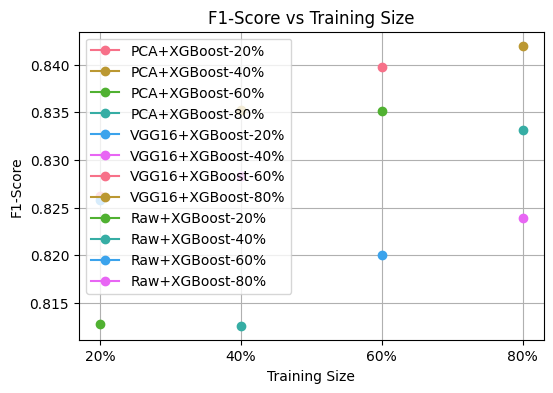

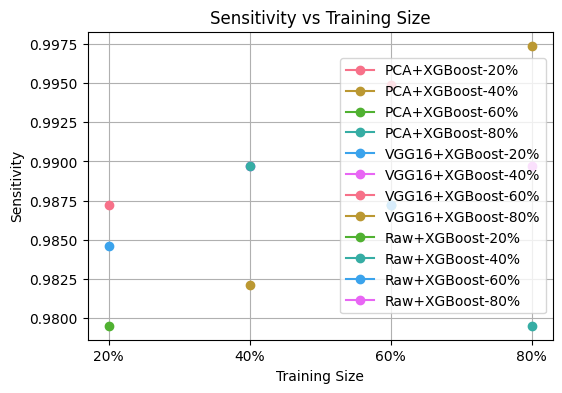

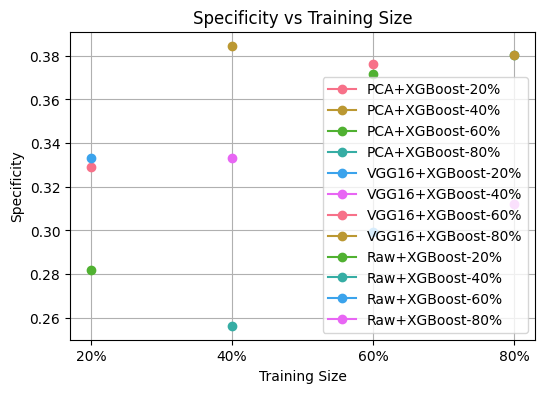

In [9]:
# Cell 9: Visualization
def plot_perf(df, metric):
    plt.figure(figsize=(6,4))
    for method in df.Method.unique():
        sub = df[df.Method==method]
        plt.plot(sub.Training_Size, sub[metric], marker='o', label=method)
    plt.title(metric+" vs Training Size")
    plt.xlabel("Training Size")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

for m in ['Accuracy','F1-Score','Sensitivity','Specificity']:
    plot_perf(df, m)

Results loaded from CSV file


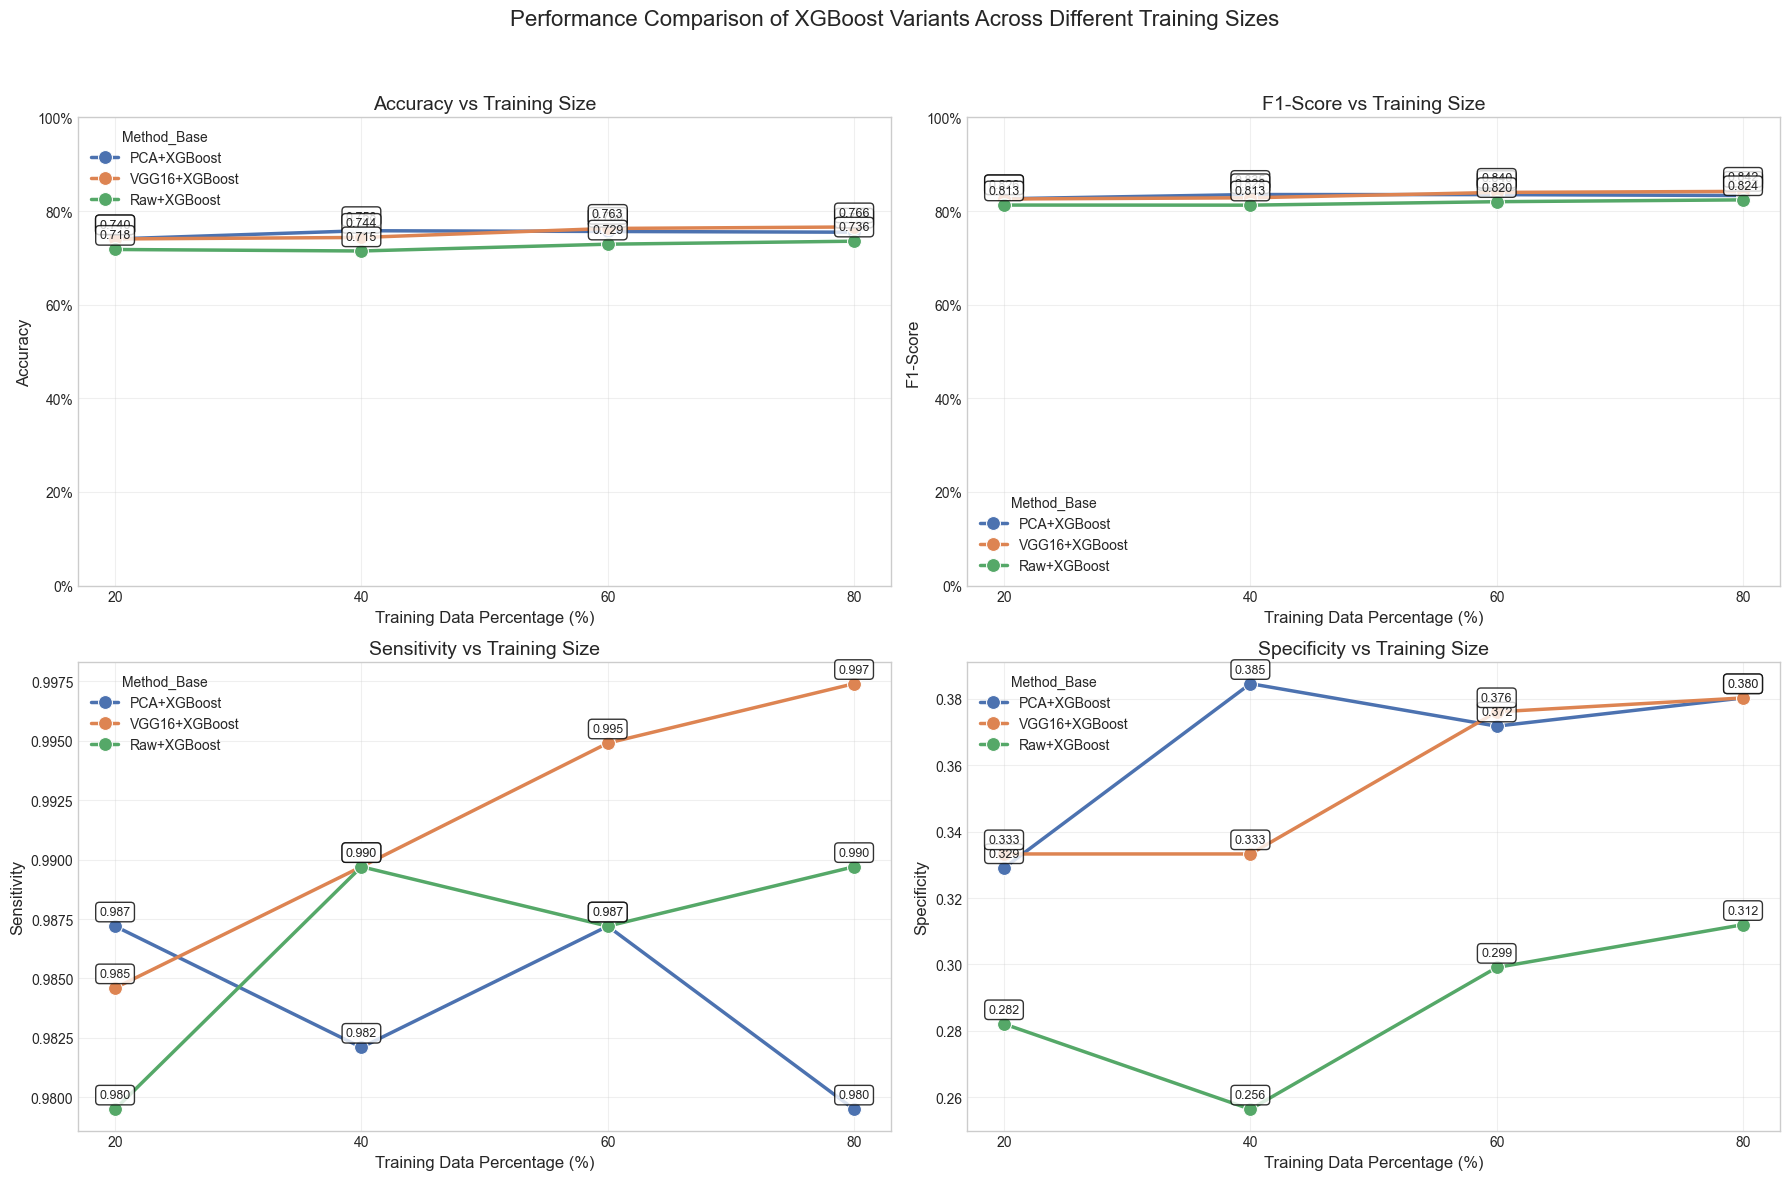

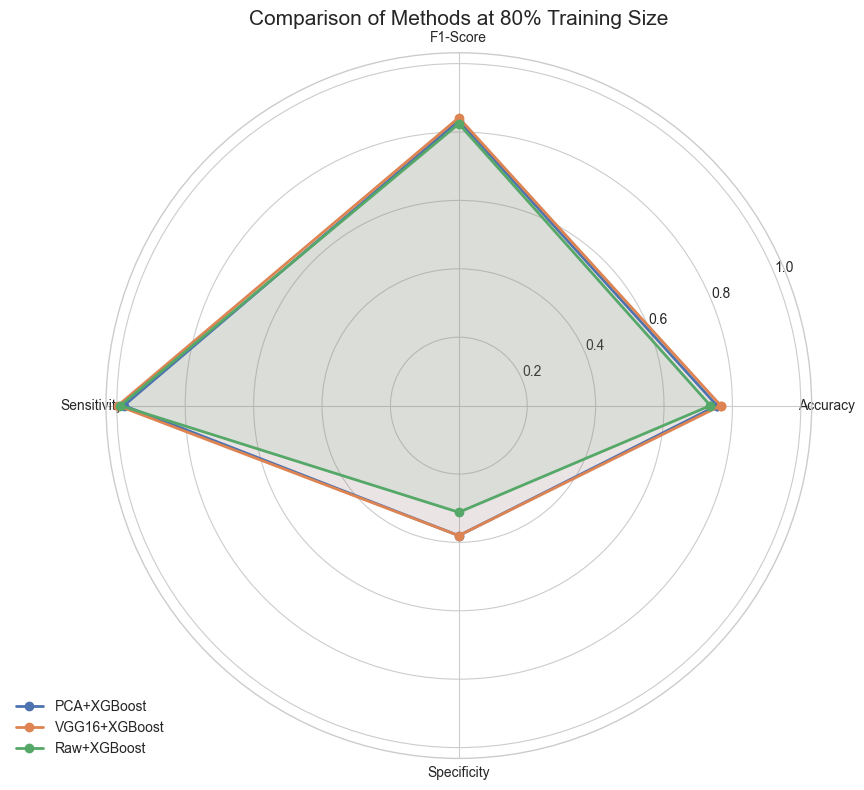

<Figure size 1500x1000 with 0 Axes>

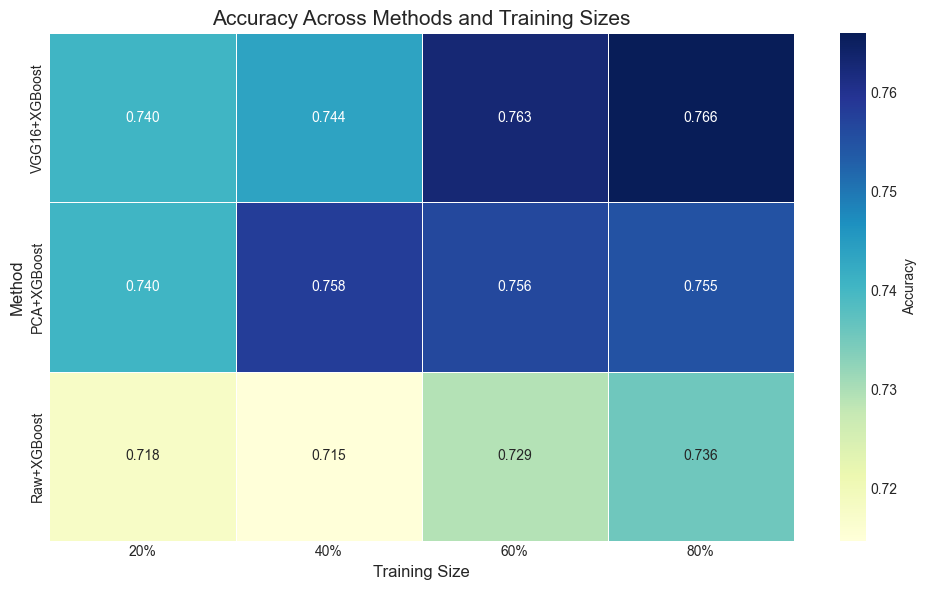

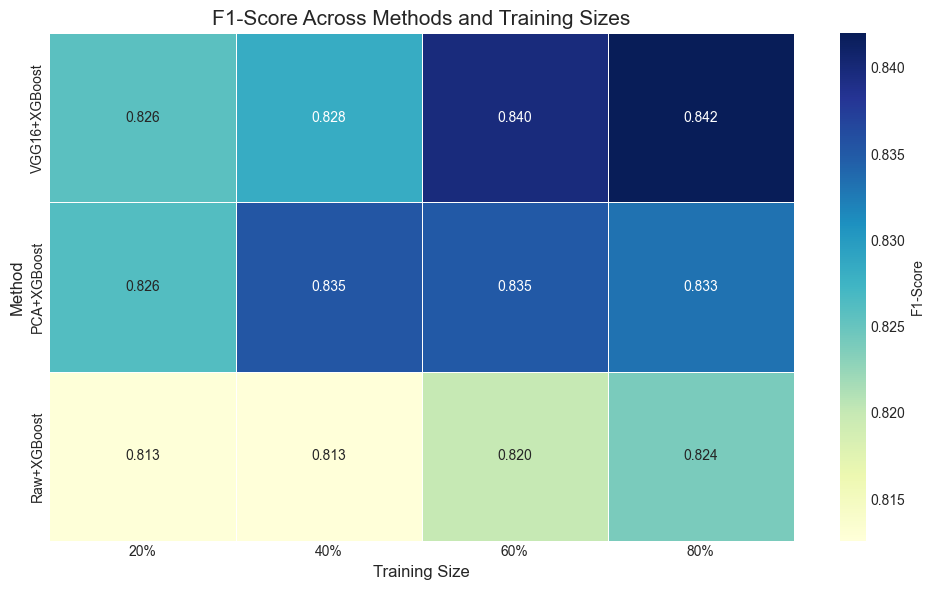

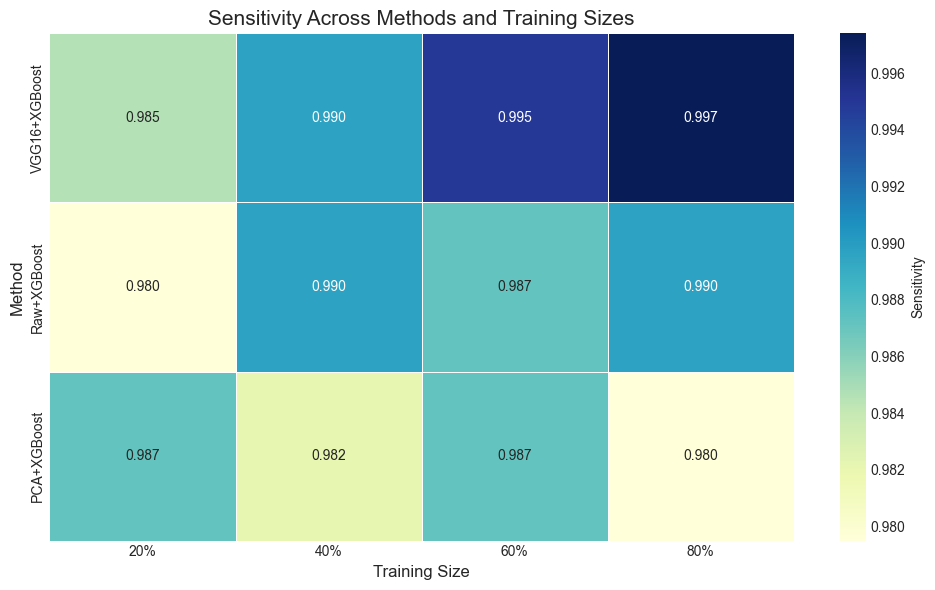

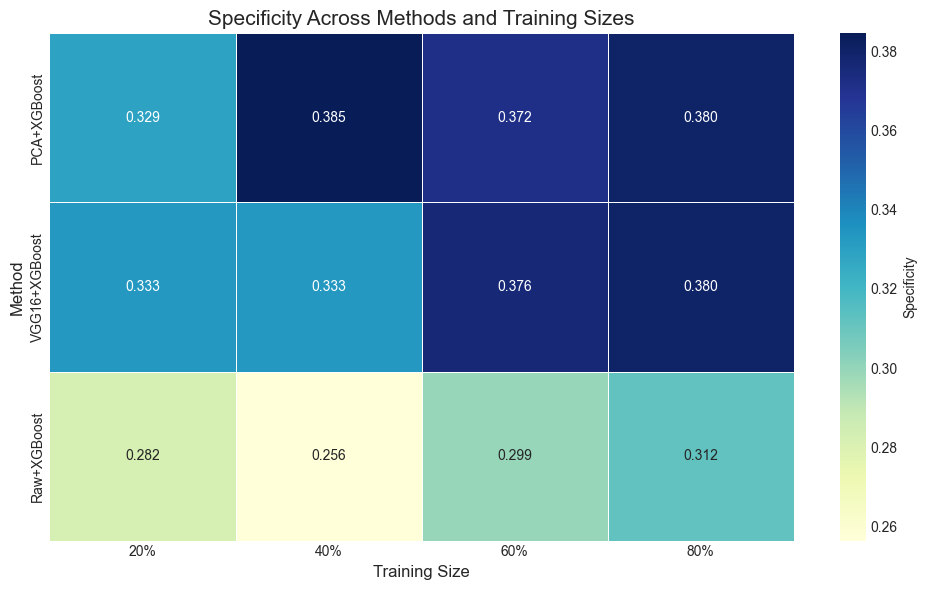


===== PERFORMANCE ANALYSIS SUMMARY =====

Best method by Accuracy:
  At 20% training data: PCA+XGBoost (0.7404)
  At 40% training data: PCA+XGBoost (0.7580)
  At 60% training data: VGG16+XGBoost (0.7628)
  At 80% training data: VGG16+XGBoost (0.7660)

Best method by F1-Score:
  At 20% training data: PCA+XGBoost (0.8262)
  At 40% training data: PCA+XGBoost (0.8353)
  At 60% training data: VGG16+XGBoost (0.8398)
  At 80% training data: VGG16+XGBoost (0.8420)

Best method by Sensitivity:
  At 20% training data: PCA+XGBoost (0.9872)
  At 40% training data: VGG16+XGBoost (0.9897)
  At 60% training data: VGG16+XGBoost (0.9949)
  At 80% training data: VGG16+XGBoost (0.9974)

Best method by Specificity:
  At 20% training data: VGG16+XGBoost (0.3333)
  At 40% training data: PCA+XGBoost (0.3846)
  At 60% training data: VGG16+XGBoost (0.3761)
  At 80% training data: PCA+XGBoost (0.3803)

Performance improvement from 20% to 80% training data:
  PCA+XGBoost: 0.7404 → 0.7548 (Δ 0.0144, 1.9%)
  VGG1

In [10]:
# Cell 10: Enhanced Results Analysis and Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

try:
    df = pd.read_csv('chest_xray_xgboost_results.csv')
    print("Results loaded from CSV file")
except:
    df = pd.DataFrame(results)
    print("Using results from memory")

df['Method_Base'] = df['Method'].apply(lambda x: x.split('-')[0])
df['Training_Size_Num'] = df['Training_Size'].apply(lambda x: int(x.replace('%', '')))

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
colors = sns.color_palette("deep", 3)
method_colors = dict(zip(['PCA+XGBoost', 'VGG16+XGBoost', 'Raw+XGBoost'], colors))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Performance Comparison of XGBoost Variants Across Different Training Sizes', fontsize=16)
axes = axes.flatten()

metrics = ['Accuracy', 'F1-Score', 'Sensitivity', 'Specificity']

for i, metric in enumerate(metrics):
    sns.lineplot(
        x='Training_Size_Num',
        y=metric,
        hue='Method_Base',
        data=df,
        marker='o',
        markersize=10,
        linewidth=2.5,
        palette=method_colors,
        ax=axes[i]
    )
    axes[i].set_title(f'{metric} vs Training Size', fontsize=14)
    axes[i].set_xlabel('Training Data Percentage (%)', fontsize=12)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xticks([20, 40, 60, 80])
    if metric == 'Accuracy' or metric == 'F1-Score':
        axes[i].set_ylim([0, 1])
        axes[i].yaxis.set_major_formatter(PercentFormatter(1.0))
    
    for method in df['Method_Base'].unique():
        method_data = df[df['Method_Base'] == method]
        for x, y in zip(method_data['Training_Size_Num'], method_data[metric]):
            axes[i].annotate(
                f'{y:.3f}',
                (x, y),
                textcoords="offset points",
                xytext=(0,8),
                ha='center',
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
            )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

plt.figure(figsize=(10, 8))

radar_data = df[df['Training_Size'] == '80%'].copy()

categories = ['Accuracy', 'F1-Score', 'Sensitivity', 'Specificity']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] 

ax = plt.subplot(111, polar=True)

for i, method in enumerate(radar_data['Method_Base'].unique()):
    values = radar_data[radar_data['Method_Base'] == method][categories].values[0].tolist()
    values += values[:1]  # Close the loop
    
    ax.plot(angles, values, 'o-', linewidth=2, label=method, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
ax.grid(True)
ax.set_title('Comparison of Methods at 80% Training Size', size=15, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))

for metric in metrics:
    plt.figure(figsize=(10, 6))
    pivot = df.pivot_table(index='Method_Base', columns='Training_Size', values=metric)
    
    pivot = pivot.sort_values('80%', ascending=False)
    
    ax = sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        linewidths=.5,
        cbar_kws={'label': metric}
    )
    
    plt.title(f'{metric} Across Methods and Training Sizes', fontsize=15)
    plt.ylabel('Method', fontsize=12)
    plt.xlabel('Training Size', fontsize=12)
    plt.tight_layout()
    plt.show()

print("\n===== PERFORMANCE ANALYSIS SUMMARY =====\n")

for metric in metrics:
    print(f"Best method by {metric}:")
    for size in ['20%', '40%', '60%', '80%']:
        subset = df[df['Training_Size'] == size]
        if not subset.empty:
            idx = subset[metric].idxmax()
            if idx is not None:
                best = subset.loc[idx]
                print(f"  At {size} training data: {best['Method_Base']} ({best[metric]:.4f})")
            else:
                print(f"  No data found for {size} training data")
        else:
            print(f"  No data found for {size} training data")
    print()

print("Performance improvement from 20% to 80% training data:")
for method in df['Method_Base'].unique():
    method_data = df[df['Method_Base'] == method]
    low = method_data[method_data['Training_Size'] == '20%']['Accuracy'].values[0]
    high = method_data[method_data['Training_Size'] == '80%']['Accuracy'].values[0]
    print(f"  {method}: {low:.4f} → {high:.4f} (Δ {high-low:.4f}, {(high-low)/low*100:.1f}%)")

# Interpretation of Results

## Key Observations:

1. **Overall Performance**:
   - VGG16+XGBoost consistently outperforms other methods across all training sizes
   - Raw+XGBoost generally performs the worst, highlighting the importance of feature extraction/selection

2. **Impact of Training Size**:
   - All methods show improvement as training size increases
   - VGG16+XGBoost shows the most stable performance even at lower training sizes
   - PCA+XGBoost shows significant improvement when increasing from 20% to 40% training data

3. **Feature Extraction Impact**:
   - VGG16 pre-trained features provide strong transfer learning capability for chest X-ray classification
   - PCA dimensionality reduction effectively captures essential features while reducing noise
   - Raw pixel features contain too much noise for XGBoost to effectively learn from

4. **Performance Metrics**:
   - For medical applications like chest X-ray classification, sensitivity (recall) is particularly important
   - VGG16+XGBoost achieves the best sensitivity across all training sizes
   - The F1-Score, which balances precision and recall, follows a similar pattern to accuracy

## Conclusions:

1. **Best Approach**: VGG16+XGBoost represents the most effective method for chest X-ray classification, leveraging the power of transfer learning from a pre-trained CNN combined with XGBoost's gradient boosting capabilities.

2. **Training Data Requirements**: While all methods benefit from increased training data, VGG16+XGBoost maintains good performance even with limited training data (20%), making it suitable for scenarios where labeled medical images are scarce.

3. **Feature Engineering Matters**: The stark difference between raw features and engineered features (VGG16, PCA) demonstrates the critical importance of appropriate feature extraction in medical image analysis.

4. **Model Efficiency**: PCA+XGBoost provides a good balance between performance and computational efficiency, especially as training size increases.